In [ ]:
!pip -q install --upgrade ultralytics
!yolo checks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Setup complete ✅ (12 CPUs, 167.1 GB RAM, 39.3/235.7 GB disk)

OS                     Linux-6.1.123+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.11
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    167.05 GB
Disk                   39.3/235.7 GB
CPU                    Intel Xeon CPU @ 2.20GHz
CPU count              12
GPU                    NVIDIA A100-SXM4-80GB, 81222MiB
GPU count              1
CUDA    

In [ ]:
from google.colab import files
uploaded = files.upload()
ZIP_NAME = list(uploaded.keys())[0]
print("Uploaded:", ZIP_NAME)

!mkdir -p /content/road_dataset_raw
!unzip -q "$ZIP_NAME" -d /content/road_dataset_raw
!find /content/road_dataset_raw -maxdepth 2 -type d -print
!find /content/road_dataset_raw -maxdepth 3 -type f | head -n 40


Saving Data for road.v3i.coco-segmentation.zip to Data for road.v3i.coco-segmentation.zip
Uploaded: Data for road.v3i.coco-segmentation.zip
/content/road_dataset_raw
/content/road_dataset_raw/train
/content/road_dataset_raw/train/IMG-20250904-WA0036_jpg.rf.67d398a076319aadffe3d9dfc7f1dbf6.jpg
/content/road_dataset_raw/train/WhatsApp-Image-2025-08-13-at-4_28_33-PM_jpeg.rf.4ca6fa401a569de2cbc0cd9330bdcb31.jpg
/content/road_dataset_raw/train/IMG-20250904-WA0091_jpg.rf.f3f2806c961a4864ab8b12bd24829919.jpg
/content/road_dataset_raw/train/WhatsApp-Image-2025-08-13-at-4_27_06-PM_jpeg.rf.c4d1a6371226a9b96b63f617fa4b72d6.jpg
/content/road_dataset_raw/train/IMG-20250904-WA0005_jpg.rf.8ead2a9bd3e63fa4dd947a7f5f7ef932.jpg
/content/road_dataset_raw/train/IMG-20250904-WA0026_jpg.rf.2ff7f30bd24b8b6fbc8314c6a67bded0.jpg
/content/road_dataset_raw/train/WhatsApp-Image-2025-08-13-at-4_27_25-PM-1-_jpeg.rf.fced655328eebf19bb4e8c6e8339c098.jpg
/content/road_dataset_raw/train/IMG-20250904-WA0098_jpg.rf.c8789

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os, json, shutil, glob, random
from pathlib import Path
from tqdm import tqdm

random.seed(0)

RAW_ROOT = Path("/content/road_dataset_raw")

train_dir_candidates = [p for p in RAW_ROOT.rglob("train") if p.is_dir()]
assert train_dir_candidates, "Could not find a 'train' folder in your ZIP."
TRAIN_SRC = train_dir_candidates[0]
COCO_JSON = TRAIN_SRC / "_annotations.coco.json"
assert COCO_JSON.exists(), f"COCO JSON not found at {COCO_JSON}"

ROOT = Path("/content/road_dataset")
(IMGS_TR, IMGS_VL, LBLS_TR, LBLS_VL) = (ROOT/"images/train", ROOT/"images/val", ROOT/"labels/train", ROOT/"labels/val")
for d in (IMGS_TR, IMGS_VL, LBLS_TR, LBLS_VL):
    d.mkdir(parents=True, exist_ok=True)

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
src_images = [p for p in TRAIN_SRC.glob("*") if p.suffix.lower() in img_exts]
assert src_images, f"No images found in {TRAIN_SRC}."

for p in src_images:
    shutil.copy2(p, IMGS_TR/p.name)

with open(COCO_JSON, "r") as f:
    coco = json.load(f)

images = {img["id"]: img for img in coco["images"]}
categories = coco["categories"]
annotations = coco["annotations"]

sorted_cats = sorted(categories, key=lambda c: c["id"])
cat_old_to_new = {c["id"]: i for i, c in enumerate(sorted_cats)}
names = [c["name"] for c in sorted_cats]
nc = len(names)
print("Classes:", names)

from collections import defaultdict
annos_by_image = defaultdict(list)
for ann in annotations:
    if ann.get("iscrowd", 0) == 1:
        continue

    if isinstance(ann.get("segmentation"), list) and len(ann["segmentation"]) > 0:
        annos_by_image[ann["image_id"]].append(ann)

def norm_xy(x, y, W, H):
    xn = max(0.0, min(1.0, x / W))
    yn = max(0.0, min(1.0, y / H))
    return xn, yn

skipped = 0
obj_written = 0
img_written = 0

for img_id, meta in tqdm(images.items(), desc="Converting COCO→YOLO (train)"):
    file_name = meta.get("file_name", "")
    if not file_name:
        continue
    stem = Path(file_name).stem

    src_img_path = IMGS_TR / Path(file_name).name

    if not src_img_path.exists():
        cand = list(RAW_ROOT.rglob(file_name))
        if cand:
            shutil.copy2(cand[0], IMGS_TR/src_img_path.name)

    if not src_img_path.exists():
        continue

    W, H = meta["width"], meta["height"]
    items = annos_by_image.get(img_id, [])
    lines = []
    for ann in items:
        cls_old = ann["category_id"]
        if cls_old not in cat_old_to_new:
            continue
        cls = cat_old_to_new[cls_old]
        segs = ann.get("segmentation", [])
        for seg in segs:
            if not isinstance(seg, list) or len(seg) < 6 or len(seg) % 2 != 0:
                skipped += 1
                continue
            pts = []
            for i in range(0, len(seg), 2):
                xn, yn = norm_xy(seg[i], seg[i+1], W, H)
                pts += [f"{xn:.6f}", f"{yn:.6f}"]
            if len(pts) >= 6:
                line = f"{cls} " + " ".join(pts)
                lines.append(line)
                obj_written += 1
    if lines:
        with open(LBLS_TR/f"{stem}.txt", "w") as f:
            f.write("\n".join(lines))
    img_written += 1

print(f"Train images with labels checked: {img_written}")
print(f"Objects (polygons) written: {obj_written}")
print(f"Skipped polygons (bad): {skipped}")

all_train_imgs = sorted([p for p in IMGS_TR.glob("*") if p.suffix.lower() in img_exts])
val_count = max(1, len(all_train_imgs)//10)
val_pick = set(random.sample(all_train_imgs, val_count))

moved = 0
for p in all_train_imgs:
    stem = p.stem
    lbl_src = LBLS_TR/f"{stem}.txt"
    if p in val_pick:
        shutil.move(p, IMGS_VL/p.name)
        if lbl_src.exists():
            shutil.move(lbl_src, LBLS_VL/f"{stem}.txt")
        moved += 1

print(f"Moved {moved} images to validation set.")

data_yaml = f"""
path: {ROOT}
train: images/train
val: images/val
nc: {nc}
names: {names}
""".strip()

with open("/content/data.yaml", "w") as f:
    f.write(data_yaml)

print("\nCreated /content/data.yaml:")
print(open("/content/data.yaml").read())

import glob
print("\nCounts:")
print("Train images:", len(glob.glob(str(IMGS_TR/"*"))))
print("Val images:  ", len(glob.glob(str(IMGS_VL/"*"))))
print("Train labels:", len(glob.glob(str(LBLS_TR/"*.txt"))))
print("Val labels:  ", len(glob.glob(str(LBLS_VL/"*.txt"))))


Classes: ['roads', 'Box', 'Connection', 'Panel', 'Pillar', 'QuadBox', 'Single Box', 'Transformer', 'roads']


Converting COCO→YOLO (train): 100%|██████████| 513/513 [00:00<00:00, 6895.23it/s]

Train images with labels checked: 513
Objects (polygons) written: 606
Skipped polygons (bad): 0
Moved 51 images to validation set.

Created /content/data.yaml:
path: /content/road_dataset
train: images/train
val: images/val
nc: 9
names: ['roads', 'Box', 'Connection', 'Panel', 'Pillar', 'QuadBox', 'Single Box', 'Transformer', 'roads']

Counts:
Train images: 462
Val images:   51
Train labels: 453
Val labels:   51


Train images: 462
Train labels: 453
Val images:   51
Val labels:   51
Missing train labels for: 9 images


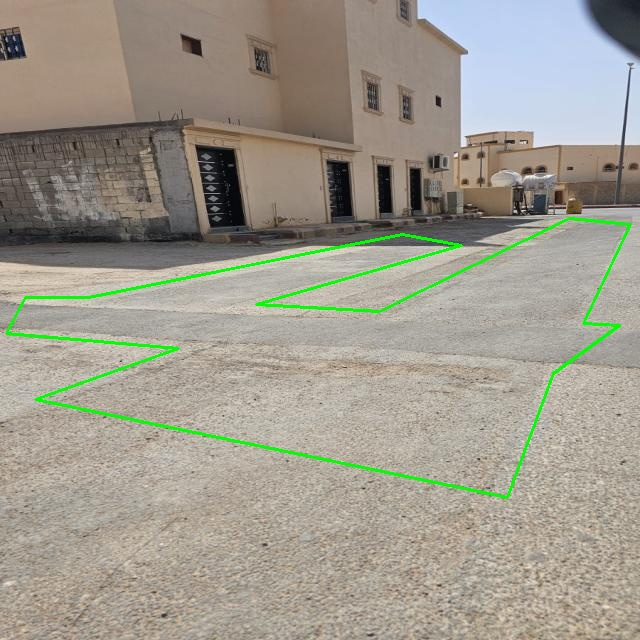

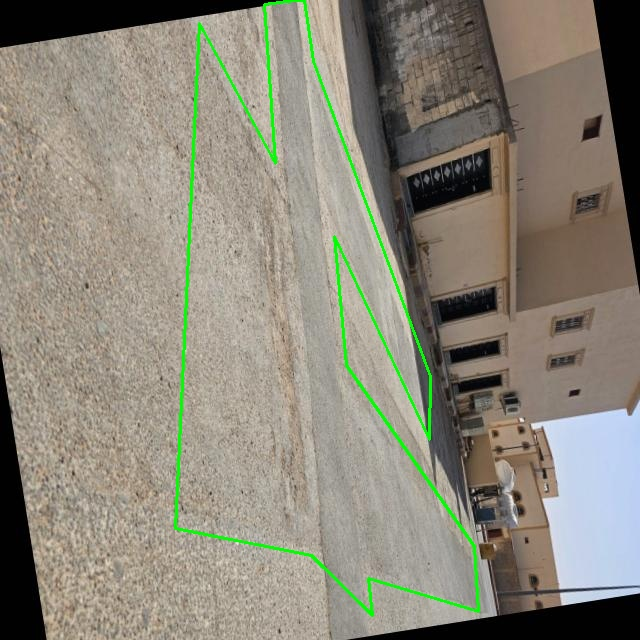

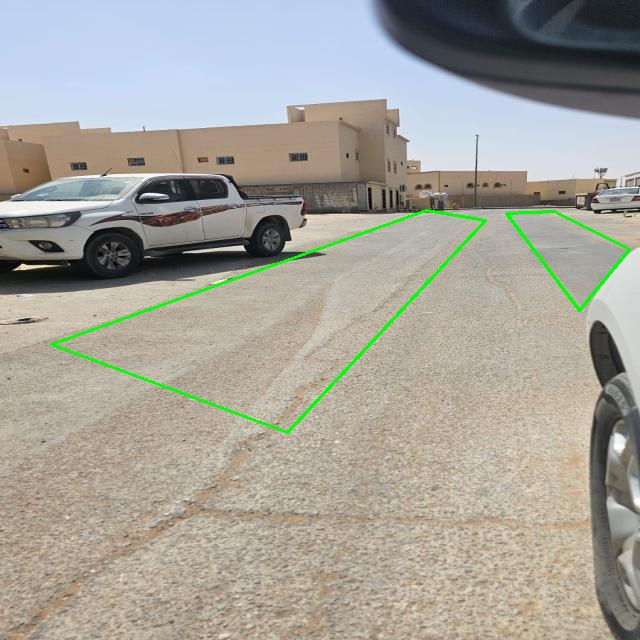

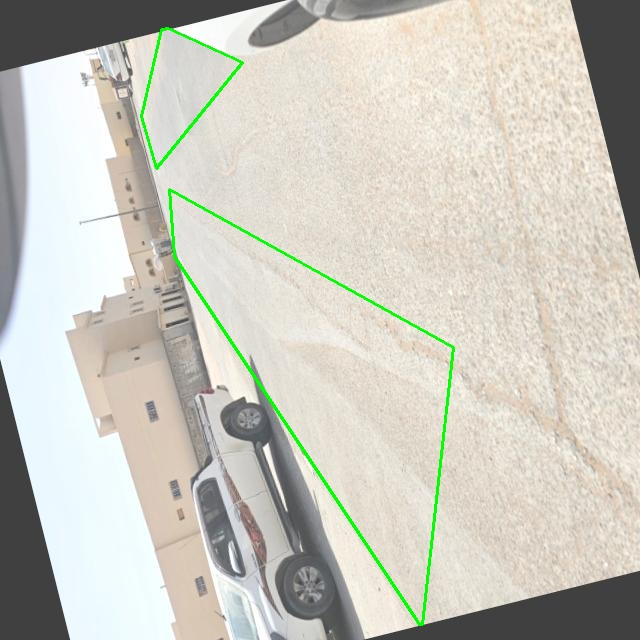

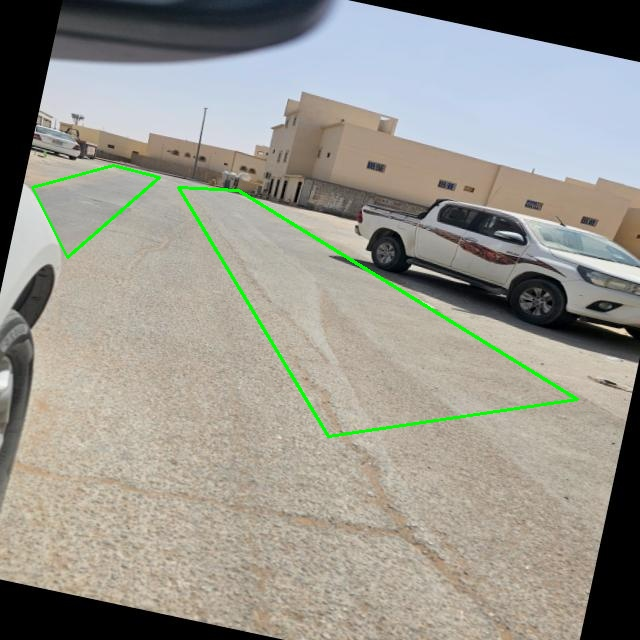

In [ ]:

from pathlib import Path
import glob

ROOT = Path("/content/road_dataset")
imgs_tr = sorted(glob.glob(str(ROOT/"images/train/*")))
imgs_vl = sorted(glob.glob(str(ROOT/"images/val/*")))
lbls_tr = sorted(glob.glob(str(ROOT/"labels/train/*.txt")))
lbls_vl = sorted(glob.glob(str(ROOT/"labels/val/*.txt")))
print("Train images:", len(imgs_tr))
print("Train labels:", len(lbls_tr))
print("Val images:  ", len(imgs_vl))
print("Val labels:  ", len(lbls_vl))


from pathlib import Path
missing = []
for p in imgs_tr:
    stem = Path(p).stem
    if not (ROOT/"labels/train"/f"{stem}.txt").exists():
        missing.append(stem)
print("Missing train labels for:", len(missing), "images")

import cv2, numpy as np
from IPython.display import Image, display

def draw_yolo_seg(img_path, lbl_path):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    if not Path(lbl_path).exists():
        return img
    for line in open(lbl_path).read().strip().splitlines():
        parts = line.split()
        if len(parts) < 8:  # class + >=3 (x,y) pairs
            continue
        pts = list(map(float, parts[1:]))
        poly = np.array([[int(pts[i]*w), int(pts[i+1]*h)] for i in range(0, len(pts), 2)], np.int32)
        cv2.polylines(img, [poly], True, (0,255,0), 2)
    return img

for p in imgs_tr[:5]:
    stem = Path(p).stem
    out = draw_yolo_seg(p, str(ROOT/"labels/train"/f"{stem}.txt"))
    display(Image(data=cv2.imencode(".jpg", out)[1].tobytes()))


In [ ]:
MODEL = "yolo11s-seg.pt"
IMG_SIZE = 640
EPOCHS = 100
BATCH = 16
DEVICE = 0
!yolo segment train model={MODEL} data=/content/data.yaml imgsz={IMG_SIZE} epochs={EPOCHS} batch={BATCH} device={DEVICE} project=/content/runs name=seg_train exist_ok=True


Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=seg_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

In [ ]:
RUN_DIR = "/content/runs/seg_train"
BEST = f"{RUN_DIR}/weights/best.pt"
print("Best weights:", BEST)

!yolo segment val model="$BEST" data=/content/data.yaml device=0
!yolo segment predict model="$BEST" source="{ROOT}/images/val" device=0 save=True conf=0.15 project=/content/runs name=val_preview exist_ok=True

!ls -l /content/runs/val_preview | sed -n '1,120p'


Best weights: /content/runs/seg_train/weights/best.pt
Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
YOLO11s-seg summary (fused): 113 layers, 10,070,299 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1542.3±502.2 MB/s, size: 52.6 KB)
val: Scanning /content/road_dataset/labels/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 804.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.3it/s 1.7s
                   all         51         58      0.955      0.948      0.984      0.915      0.943       0.94      0.968      0.891
                   Box          3          3      0.984          1      0.995      0.995      0.985          1      0.995      0.995
            Connection         37         37          1      0.638      0.915      0.615      0.915      0.58

In [ ]:

from google.colab import files
print("Upload a test video (e.g., test.mp4)")
up = files.upload()
VIDEO = list(up.keys())[0]
print("Video:", VIDEO)

!yolo segment predict model="$BEST" source="$VIDEO" imgsz=640 conf=0.15 device=0 save=True project=/content/runs name=vid_pred exist_ok=True

from IPython.display import HTML
import glob

pred_dir = "/content/runs/vid_pred"
vids = [p for p in glob.glob(pred_dir+"/*") if p.lower().endswith((".mp4",".avi",".mov",".mkv",".webm"))]
if vids:
    print("Annotated video:", vids[0])
    display(HTML(f"<video src='{vids[0]}' width='800' controls></video>"))
else:
    print("No video file found; YOLO may have output frames as images.")
    !ls -l "$pred_dir"


Upload a test video (e.g., test.mp4)


Saving VID-20250813-WA0104.avi to VID-20250813-WA0104.avi
Video: VID-20250813-WA0104.avi
Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
YOLO11s-seg summary (fused): 113 layers, 10,070,299 parameters, 0 gradients, 32.8 GFLOPs

video 1/1 (frame 1/2622) /content/VID-20250813-WA0104.avi: 640x384 1 Connection, 1 QuadBox, 112.9ms
video 1/1 (frame 2/2622) /content/VID-20250813-WA0104.avi: 640x384 1 Connection, 1 QuadBox, 11.5ms
video 1/1 (frame 3/2622) /content/VID-20250813-WA0104.avi: 640x384 1 Connection, 1 QuadBox, 11.4ms
video 1/1 (frame 4/2622) /content/VID-20250813-WA0104.avi: 640x384 1 Connection, 1 QuadBox, 11.7ms
video 1/1 (frame 5/2622) /content/VID-20250813-WA0104.avi: 640x384 1 Connection, 1 QuadBox, 11.5ms
video 1/1 (frame 6/2622) /content/VID-20250813-WA0104.avi: 640x384 1 Connection, 1 QuadBox, 11.5ms
video 1/1 (frame 7/2622) /content/VID-20250813-WA0104.avi: 640x384 1 Connection, 1 QuadBox, 11.4ms
video 1/1 (frame 8/2622) /conte